## **Preprocessing**

In [2]:
from datasets import load_dataset
import pandas as pd
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import emoji
import unicodedata
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from bs4 import BeautifulSoup
import re
import seaborn as sns
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import string

### Dataset loading

In [3]:
ds = load_dataset("Kanakmi/mental-disorders")

Repo card metadata block was not found. Setting CardData to empty.


### Dataset overview
| Item        | Value                                   |
|-------------|-----------------------------------------|
| Dataset     | `Kanakmi/mental-disorders`              |
| Size  | ~581,000 texts                          |
| Language      | English                                 |
| Style    | Forum style: informal, conversational |
| Features       | `text` (description), `label` (int 0–5)|

### Label Mapping
| label (int) | class         |
|------------:|----------------|
| 0           | BPD            |
| 1           | bipolar        |
| 2           | depression     |
| 3           | anxiety        |
| 4           | schizophrenia  |
| 5           | mentalillness  |




In [4]:
type(ds)

datasets.dataset_dict.DatasetDict

In [5]:
df_train = pd.DataFrame(ds['train'])

df_test = pd.DataFrame(ds['test'])

df_val = pd.DataFrame(ds['val'])


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465051 entries, 0 to 465050
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    465051 non-null  object
 1   label   465051 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.1+ MB


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23190 entries, 0 to 23189
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    23190 non-null  object
 1   label   23190 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 362.5+ KB


In [8]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92976 entries, 0 to 92975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    92976 non-null  object
 1   label   92976 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.4+ MB


### Combined Dataset (Train, Validation, and Test)


In [9]:
mental_df = pd.concat([df_train, df_val, df_test], ignore_index=True)


In [10]:
mental_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581217 entries, 0 to 581216
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    581217 non-null  object
 1   label   581217 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 8.9+ MB


In [11]:
mental_df.head()

,text,label
0,My father - all of my life - has shifted betwe...,0
1,I have health anxiety where I go to the doctor...,3
2,I was thinking about the differences between B...,0
3,Let me preface this by saying that I promise I...,2
4,"I've been exploring this forum for awhile, and...",0


## Data exploration and visualization

### No. of occurrences for each class

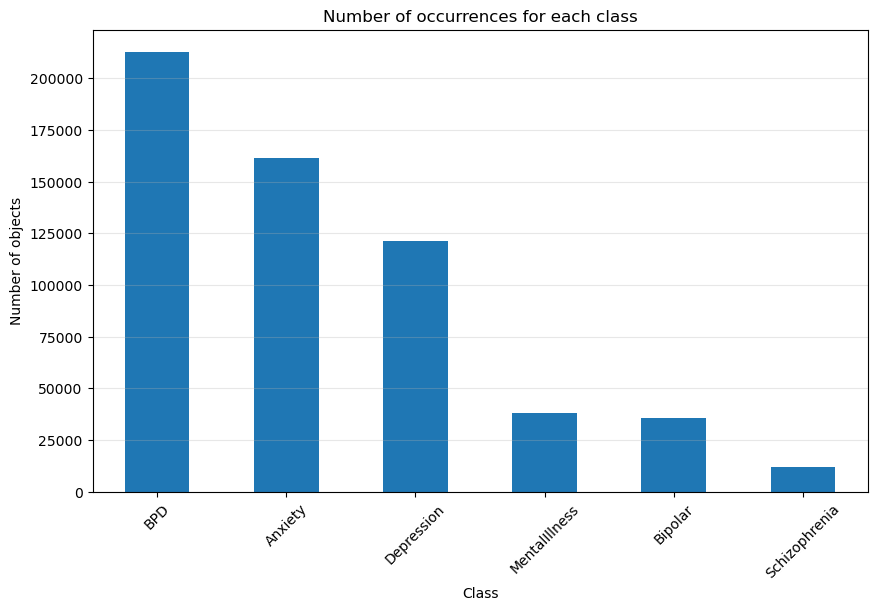

In [12]:
label_dict = {
    0: "BPD",
    1: "Bipolar",
    2: "Depression",
    3: "Anxiety",
    4: "Schizophrenia",
    5: "MentalIllness"
}

counts = mental_df.groupby('label').size().sort_values(ascending=False)
plt.figure(figsize= (10,6))
counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of objects')

plt.xticks(ticks=range(len(counts)), labels=[label_dict[i] for i in counts.index], rotation=45)

plt.title('Number of occurrences for each class')
plt.grid(axis= 'y', alpha= 0.3)
plt.show()
plt.close()

### Distribution of categories (% share)

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/2496984068.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')


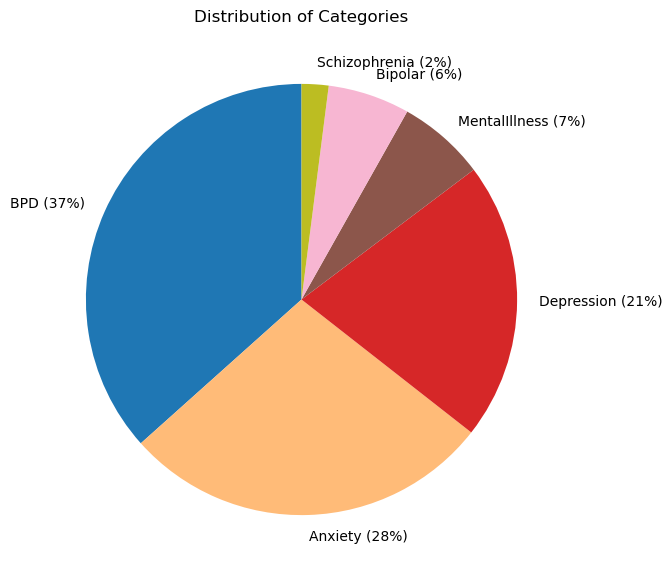

In [13]:
data = mental_df.groupby('label').size().sort_values(ascending= False)
percentages = (data / data.sum()) * 100
labels = [f"{label_dict[label]} ({value:.0f}%)" for label, value in zip(data.index, percentages)]

cmap = get_cmap('tab20')
colors = [cmap(i / len(data)) for i in range(len(data))]

plt.figure(figsize=(10, 7))
plt.pie(
    data, 
    labels=labels,
    colors= colors,
    startangle=90
)
plt.title('Distribution of Categories')
plt.show()
plt.close()

### Text length analysis

In [14]:
# Calculate the average text length
mental_df['text_length'] = mental_df['text'].apply(len)
print(mental_df['text_length'].describe())  # Display statistics about text length

# Show one sample text for each label
for label in mental_df['label'].unique():
    print(f"Texts for label {label}:")
    print(mental_df[mental_df['label'] == label]['text'].head(1))  
    print()

mental_df

count    581217.000000
mean        912.487162
std        1051.651589
min           1.000000
25%         324.000000
50%         628.000000
75%        1141.000000
max       33565.000000
Name: text_length, dtype: float64
Texts for label 0:
0    My father - all of my life - has shifted betwe...
Name: text, dtype: object

Texts for label 3:
1    I have health anxiety where I go to the doctor...
Name: text, dtype: object

Texts for label 2:
3    Let me preface this by saying that I promise I...
Name: text, dtype: object

Texts for label 1:
16    Hi, first time poster, I'm not bipolar, but my...
Name: text, dtype: object

Texts for label 5:
17    [deleted]
Name: text, dtype: object

Texts for label 4:
22    Does anyone else get frequent delusions that n...
Name: text, dtype: object



,text,label,text_length
0,My father - all of my life - has shifted betwe...,0,2892
1,I have health anxiety where I go to the doctor...,3,243
2,I was thinking about the differences between B...,0,544
3,Let me preface this by saying that I promise I...,2,3078
4,"I've been exploring this forum for awhile, and...",0,1535
...,...,...,...
581212,While trying to park today I accidentally scra...,3,450
581213,i feel so much guilt and hatred for everything...,2,2827
581214,Because... how? How do you know what you like ...,0,344
581215,Every time I try it gets worse. When I just si...,2,275


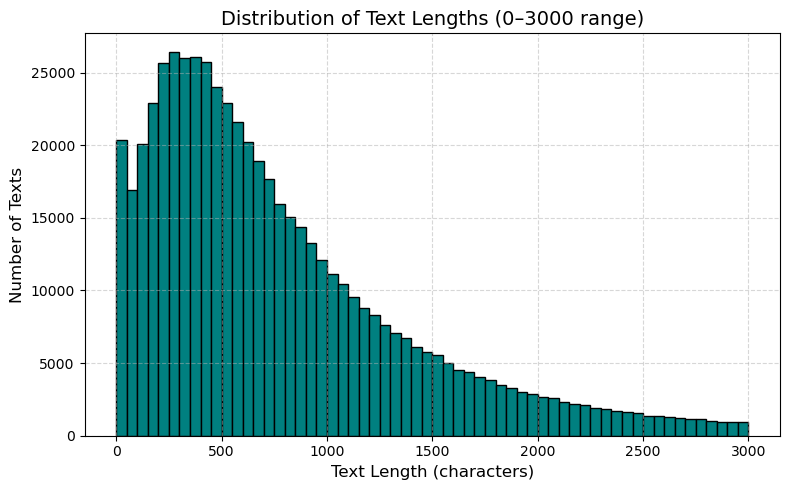

In [15]:
# Visualize the distribution of text lengths
plt.figure(figsize=(8, 5))
plt.hist(mental_df['text_length'], bins=60, color='teal', edgecolor='black', range=(0, 3000))
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Number of Texts', fontsize=12)
plt.title('Distribution of Text Lengths (0–3000 range)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


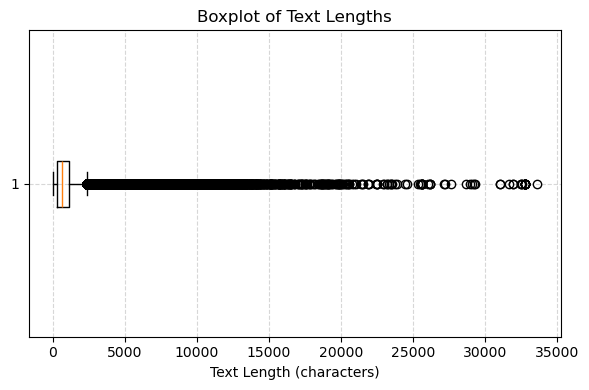

In [16]:
# Boxplot of text lengths
plt.figure(figsize=(6, 4))
plt.boxplot(mental_df['text_length'], vert=False)
plt.xlabel('Text Length (characters)')
plt.title('Boxplot of Text Lengths')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


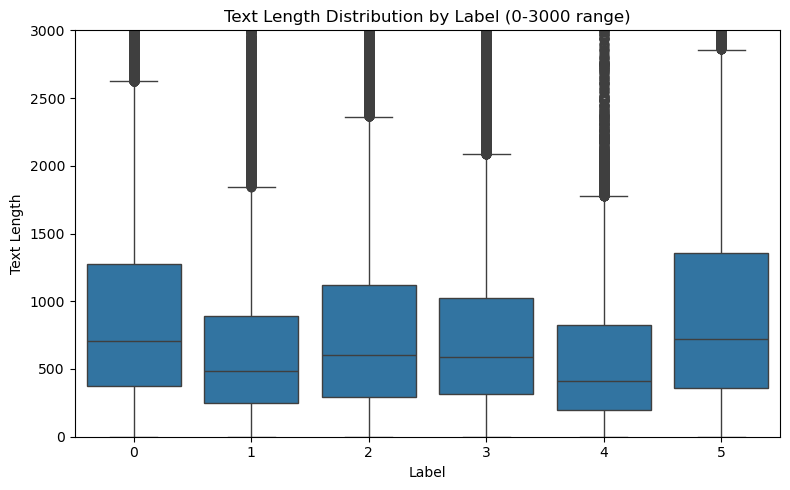

In [17]:
# Boxplot of text lengths by label

plt.figure(figsize=(8, 5))
sns.boxplot(data=mental_df, x='label', y='text_length')
plt.ylim(0, 3000)  
plt.xlabel('Label')
plt.ylabel('Text Length')
plt.title('Text Length Distribution by Label (0-3000 range)')
plt.tight_layout()
plt.show()


### Emoji usage across the dataset

The dataset contains 581,217 text entries with a mean emoji count of 0.052, indicating emojis appear in only ~5% of texts. The distribution is highly skewed: all three quartiles equal zero, meaning at least 75% of texts contain no emojis. The standard deviation of 0.56 relative to the mean confirms the presence of outliers, with a maximum of 176 emojis in a single text potentially indicating spam or data quality issues. This extreme sparsity suggests limited utility for predictive modeling.

In [18]:
# Count the number of emojis in a text string
def count_emojis(text):
    if not isinstance(text, str):
        return 0 # Return 0 if text is not a string
    return len(emoji.emoji_list(text)) # Return the total number of emojis found in the text

mental_df['emoji_count'] = mental_df['text'].apply(count_emojis)
print(mental_df['emoji_count'].describe())  # Display statistics about emoji count


count    581217.000000
mean          0.052399
std           0.561724
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         176.000000
Name: emoji_count, dtype: float64


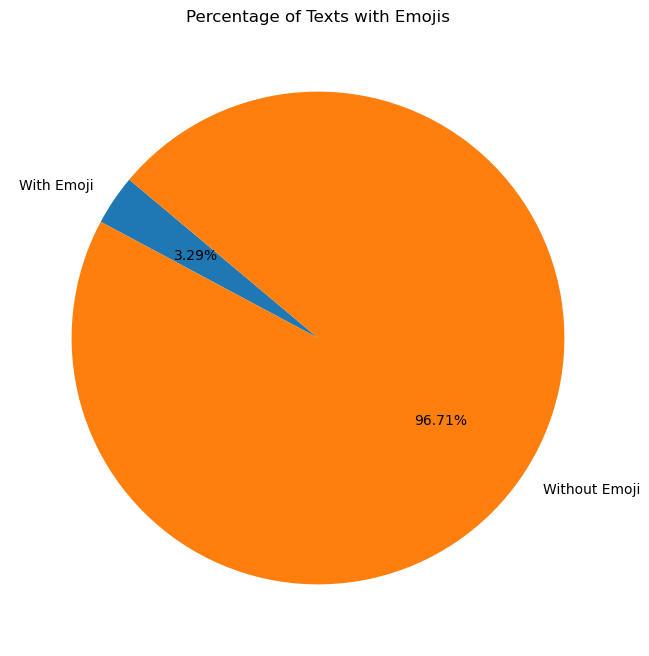

In [21]:
# Pie chart showing the percentage of texts with emojis
mental_df["has_emoji"] = mental_df["emoji_count"] > 0 # Create binary feature indicating emoji presence
emoji_counts = mental_df['has_emoji'].value_counts().sort_index(ascending=False)
labels = ['With Emoji', 'Without Emoji']

plt.figure(figsize=(8, 8))
plt.pie(emoji_counts, labels=labels, autopct='%1.2f%%', startangle=140)
plt.title('Percentage of Texts with Emojis')
plt.show()

In [22]:
# Total count of texts with emojis
total_with_emoji = mental_df['has_emoji'].sum()
percentage_with_emoji = (total_with_emoji / len(mental_df)) * 100
print(f"Total texts with emojis: {total_with_emoji} ({percentage_with_emoji:.2f}%)")

Total texts with emojis: 19150 (3.29%)


### Distribution of emojis across labels

Emoji usage varies across mental health conditions. Bipolar disorder and anxiety show the highest presence (~4.0-4.2%), followed by BPD (~3.3%) and general mental illness discussions (~3.0%). Schizophrenia and depression have the lowest rates (~2.3%). However, these differences are minimal, and overall emoji usage remains very low across all categories, suggesting limited discriminative power for classification tasks.

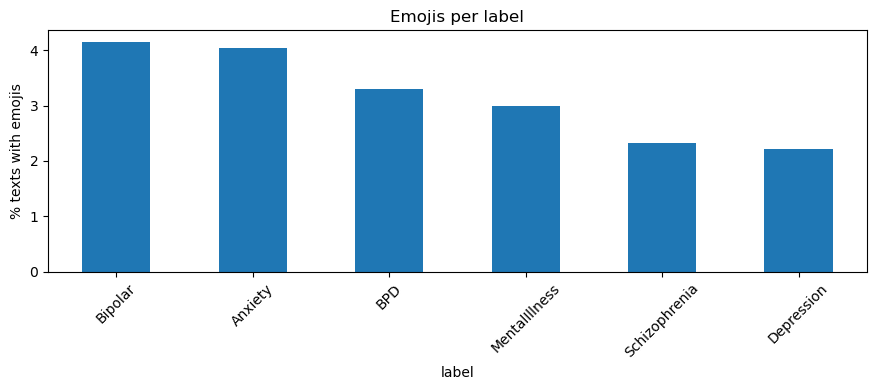

In [23]:
pct = (
    mental_df.groupby("label")["has_emoji"]
    .mean()
    .sort_values(ascending=False) * 100
)

pct.index = pct.index.map(label_dict) 

plt.figure(figsize=(9, 4))
pct.plot(kind="bar")
plt.ylabel("% texts with emojis")
plt.title("Emojis per label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data cleaning

### 1 - Deleting Non-English Texts

In [24]:
# Language Detection
DetectorFactory.seed = 0

def detect_language(text):
    """
    Detect the language of a given text.
    Returns the language code or None if detection fails.
    """
    try:
        return detect(text)
    except LangDetectException:
        return None

# Apply language detection to the dataframe
mental_df['language'] = mental_df['text'].apply(detect_language)

# Check language distribution
print(f"\nTotal rows: {len(mental_df)}")
print("\nOverall Language distribution (%):")
language_dist_percent = mental_df['language'].value_counts(normalize=True) * 100
print(language_dist_percent.round(3))  # Rounded to 3 decimal places

# Count of non-English languages
non_english_counts = mental_df[mental_df['language'] != 'en']['language'].value_counts()
print("\nNon-English language counts:")
print(non_english_counts)

# Remove non-English texts from the dataframe
mental_df = mental_df[mental_df['language'] == 'en']

print(f"\nRows after keeping only English texts: {len(mental_df)}")

# Drop the language column
mental_df.drop('language', axis=1, inplace=True)



Total rows: 581217

Overall Language distribution (%):
language
en       97.866
da        1.701
af        0.045
no        0.038
nl        0.035
es        0.027
de        0.027
ca        0.025
tr        0.023
fr        0.023
tl        0.023
et        0.021
so        0.019
it        0.019
cy        0.018
id        0.012
pl        0.012
pt        0.012
sv        0.011
ro        0.006
sw        0.006
sq        0.006
vi        0.006
fi        0.005
hr        0.003
sk        0.002
sl        0.002
hu        0.002
lv        0.002
lt        0.001
cs        0.001
ru        0.000
ja        0.000
el        0.000
hi        0.000
fa        0.000
zh-tw     0.000
zh-cn     0.000
bg        0.000
ar        0.000
uk        0.000
ko        0.000
Name: proportion, dtype: float64

Non-English language counts:
language
da       9877
af        262
no        218
nl        205
es        156
de        154
ca        144
tr        136
fr        135
tl        133
et        123
so        111
it        108
cy       

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/2829107566.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mental_df.drop('language', axis=1, inplace=True)


### 2 - Identifying and Printing Text Entries Composed Only of Punctuation and Emojis



This returns 0 entries as the language detection step above already removed texts with only punctuation and emojis, since they cannot be classified as English.   
Note: Running this check before the language detection step would return 344 entries, confirming that the language filtering effectively removes such non-textual content.

In [25]:
# Keeps only strings made EXCLUSIVELY of characters that are neither \w (word chars) nor \s (spaces) 
# e.g. ., ! ? ; : ...
mask_only_punct = (mental_df["text"]
        .fillna("")       # replace NaN with empty string
        .str.strip()      # remove leading/trailing spaces
        .str.match(r'^[^\w\s]+$', na=False))  # match only strings made entirely of non-word and non-space characters (so only punctuation/emojis)

# Print the rows that meet the condition
print(mental_df.loc[mask_only_punct, "text"].to_string(index=True))

total = mask_only_punct.sum()
print("Total number of texts containing only punctuation and/or emojis:", total)

Series([], )
Total number of texts containing only punctuation and/or emojis: 0


In [26]:
# Filter out texts composed solely of punctuation and/or emojis
mental_df = mental_df[~mask_only_punct]  # The tilde (~) inverts the mask
print(f"Dataset shape after filtering: {mental_df.shape}")

Dataset shape after filtering: (568266, 5)


### 3 - Filtering Text Entries by Length


In [27]:
# Analyzing the number of rows that would be removed at various text length thresholds

thresholds = [10, 50, 100, 150, 200]

total_rows = mental_df.shape[0]
print(f"Total texts: {total_rows}\n")

for t in thresholds:
    num_removed = mental_df[mental_df["text_length"] <= t].shape[0]
    perc_removed = num_removed / total_rows * 100
    print(f"If you remove texts with ≤ {t} characters:")
    print(f"   - Total number of removed texts: {num_removed}")
    print(f"   - Percentual: {perc_removed:.2f}%\n")


Total texts: 568266

If you remove texts with ≤ 10 characters:
   - Total number of removed texts: 276
   - Percentual: 0.05%

If you remove texts with ≤ 50 characters:
   - Total number of removed texts: 8613
   - Percentual: 1.52%

If you remove texts with ≤ 100 characters:
   - Total number of removed texts: 25231
   - Percentual: 4.44%

If you remove texts with ≤ 150 characters:
   - Total number of removed texts: 45262
   - Percentual: 7.96%

If you remove texts with ≤ 200 characters:
   - Total number of removed texts: 68186
   - Percentual: 12.00%



Texts shorter than or equal to 200 characters are removed to ensure sufficient linguistic content, resulting in the exclusion of 12% of the dataset.


In [28]:
# Keep only texts that are longer than 200 characters

mental_df = mental_df[mental_df["text_length"] > 200]

mental_df.shape

(500080, 5)

### 4 - Identifying NaN values and empty strings/spaces


In [29]:
num_nan = mental_df["text"].isna().sum()
num_empty = mental_df["text"].str.strip().eq("").sum()

print(f"NaN texts: {num_nan}")
print(f"Empty texts: {num_empty}")
print(f"Total: {num_nan + num_empty}")

NaN texts: 0
Empty texts: 0
Total: 0


In [30]:
# Remove rows with NaN or empty text values
mask_valid = mental_df["text"].notna() & (mental_df["text"].str.strip() != "")
mental_df = mental_df[mask_valid]
print(f"Dataset shape after filtering: {mental_df.shape}")

Dataset shape after filtering: (500080, 5)


#### 5 - Identifying emails, url and paths 

In [31]:
# Define a pattern to match URLs or emails
pattern = r"(https?://\S+|www\.\S+|\S+@\S+\.\S+)"

# Create a mask: True for rows that contain URLs or @
mask_url_emails = mental_df["text"].str.contains(pattern, na=False, regex=True)

# Filter the DataFrame
num_paths_df = mental_df[mask_url_emails]

# Print the total number of matching rows
num_paths = num_paths_df.shape[0]
print(f"\n Total matching rows: {num_paths}")

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/2997354491.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_url_emails = mental_df["text"].str.contains(pattern, na=False, regex=True)



 Total matching rows: 6835


In [32]:
# Filter out texts that include URLs or email addresses
mental_df = mental_df[~mask_url_emails]
mental_df.shape

(493245, 5)

### 6 - Identifying duplicates 

In [33]:
# Normalize texts (remove extra spaces, etc.)
normalized_text = (
    mental_df["text"]
    .astype(str)
    .str.strip()
    .str.split()
    .str.join(" ")
)

# Group by normalized text to find duplicates
duplicate_groups = []
total_dup_rows = 0

for text, group in mental_df.groupby(normalized_text):
    if len(group) > 1: # Text appears more than once
        total_dup_rows += len(group) # Count all occurrences
        duplicate_groups.append({
            "text": text,
            "count": len(group),
            "indices": list(group.index)
        })

print("Total duplicated rows:", total_dup_rows)  # Total number of duplicate rows (counting all occurrences of duplicated texts)
print("Total unique duplicated texts:", len(duplicate_groups)) # Number of distinct texts that have duplicates


Total duplicated rows: 11270
Total unique duplicated texts: 4634


In [34]:
# Filter out duplicate texts, retaining only the first instance
mental_df = mental_df.loc[~normalized_text.duplicated(keep="first")].copy()
mental_df.shape

(486609, 5)

### 7 - Removing emojis from texts 

In [35]:
# Filter out all emojis from the text data
def remove_emojis(text):
        # Replace emojis with empty strings
    return emoji.replace_emoji(text, replace='') 
# Save original text to track modifications
original_text = mental_df["text"].copy()
# Apply emoji removal to all texts
mental_df["text"] = mental_df["text"].apply(remove_emojis)
# Count how many rows were modified (contained at least one emoji)
num_modified = (mental_df["text"] != original_text).sum()
print(f"Number of modified rows after removing emojis: {num_modified}")


Number of modified rows after removing emojis: 16502


### 8 - Identify text that only cointains digits

In [36]:
# Match rows that contain only digits (after stripping spaces)
mask_only_numbers = (
    mental_df["text"]
    .astype(str)
    .str.strip()
    .str.fullmatch(r"\d+")   # matches only sequences of digits
)

# Print the rows that will be removed
print("Rows containing only numbers:")
print(mental_df[mask_only_numbers])

# Remove rows containing only numeric characters
mental_df = mental_df[~mask_only_numbers].copy()

print(f"\nRows removed: {mask_only_numbers.sum()}")
print(f"Remaining rows: {len(mental_df)}")


Rows containing only numbers:
Empty DataFrame
Columns: [text, label, text_length, emoji_count, has_emoji]
Index: []

Rows removed: 0
Remaining rows: 486609


### 9 - Identify and remove markup tags

In [37]:
# Cleaning functions 
def remove_html_xml_tags(text: str) -> str:
    # Parse text as XML first (more strict), fallback to HTML if parsing fails
    try:
        soup = BeautifulSoup(str(text), "xml")
        cleaned = soup.get_text()
        # If result is empty or only spaces, try HTML parser
        if not cleaned.strip():
            soup = BeautifulSoup(str(text), "html.parser")
            cleaned = soup.get_text()
    except Exception:
        # fallback to HTML parser on any parsing error
        soup = BeautifulSoup(str(text), "html.parser")
        cleaned = soup.get_text()
    
    # Remove any leftover tags that might not have been caught
    cleaned = re.sub(r"<[^>]+>", "", cleaned)
    return cleaned

# Dataset cleaning 
print("Initial shape:", mental_df.shape)

# Save original text for comparison
original_texts = mental_df["text"].copy()

# Apply cleaning
cleaned_series = original_texts.apply(remove_html_xml_tags)

# Count modified rows
num_modified = (cleaned_series != original_texts).sum()
print(f"Modified rows: {num_modified}")

# Replace original column
mental_df["text"] = cleaned_series

print("Final dataset shape:", mental_df.shape)

# show sample of modifications
print("\n--- Sample of modified texts (before → after) ---\n")
diff_mask = cleaned_series != original_texts
changed = original_texts[diff_mask]

for i, idx in enumerate(changed.index[:10]):
    print(f"Example {i+1}:")
    print("Before:", original_texts[idx])
    print("After: ", cleaned_series[idx])
    print("-" * 80)


Initial shape: (486609, 5)


/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/139907328.py:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(str(text), "xml")
/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/139907328.py:9: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(str(text), "html.parser")


Modified rows: 21752
Final dataset shape: (486609, 5)

--- Sample of modified texts (before → after) ---

Example 1:
Before: It's really tiring,,

Someone is angry? I'll be upset too.

Someone is sad? Well now time to want to die as well.

I feel guilt because my friend is not really having a good day even if I had nothing to do with making him feel unwell in any way. Yet it's all my fault somehow, that's what my brain is telling me. I try to be happy around him so he feels better but I'm just making it worse, annoying him. It's like, my life revolves around this person as of now, so if they feel sad, that's how it's gonna be for me as well. How do I just stop feeling so much. I'm usually ok because I'm just numb but now I can't do it, I'm just attacked by unnecessary feelings.

&amp;#x200B;

To clarify, it's not feeling sad about someone feeling sad. It becoming sad in general for yourself due to someone else being that way. Weird to describe.
After:  It's really tiring,,

Someone is 

### 10 - Identify and remove special characters

In [38]:
def fix_line_terminators(text):
    if not isinstance(text, str):
        return text, 0

# Dictionary mapping unusual line terminators to standard replacements
    unusual_terminators = {
        '\u2028': ' ',  # Line Separator
        '\u2029': ' ',  # Paragraph Separator
        '\u0085': ' ',  # Next Line (NEL)
        '\u000B': ' ',  # Vertical Tab
        '\u000C': ' ',  # Form Feed
        '\r\n': '\n',   # Windows line ending
        '\r': '\n',     # Old Mac line ending
    }

    count = 0
    cleaned_text = text

    # Replace each unusual terminator with its standard equivalent
    for old, new in unusual_terminators.items():
        if old in cleaned_text:
            occurrences = cleaned_text.count(old)
            cleaned_text = cleaned_text.replace(old, new)
            count += occurrences

    return cleaned_text, count


# Apply the function to the df
num_modified = 0
total_replacements = 0
cleaned_texts = []

for text in mental_df["text"]:
    cleaned, replacements = fix_line_terminators(text)
    cleaned_texts.append(cleaned)
    if replacements > 0:
        num_modified += 1
        total_replacements += replacements

mental_df["text"] = cleaned_texts

print("Line terminators fixed.")
print(f"Texts modified: {num_modified}")
print(f"Total replacements: {total_replacements}")
print(f"DataFrame shape: {mental_df.shape}")

Line terminators fixed.
Texts modified: 11
Total replacements: 113
DataFrame shape: (486609, 5)


In [39]:
def clean_english_text(text):
    if not isinstance(text, str) or not text:
        return text
    
    # Normalize Unicode (NFKC)
    text = unicodedata.normalize('NFKC', text)
    
    # Remove replacement characters
    text = text.replace('\ufffd', '')
    
    # Remove zero-width characters
    zero_width_chars = ['\u200b', '\u200c', '\u200d', '\ufeff']
    for char in zero_width_chars:
        text = text.replace(char, '')
    
    # Remove non-printable characters (keep spaces, newline, tab)
    text = ''.join(
        char for char in text
        if unicodedata.category(char)[0] != 'C' or char in ' \n\t\r'
    ) 
    
    # Convert accented letters to ASCII
    text = unicodedata.normalize('NFD', text)
    text = ''.join(char for char in text if unicodedata.category(char) != 'Mn')
    
    # Keep only standard ASCII characters + common punctuation
    text = re.sub(r'[^\x20-\x7E]', ' ', text)
    
    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Apply the function and collect statistics
print("Applying clean_english_text...")

# Copy original texts for comparison
original_texts = mental_df['text'].copy()

# Apply cleaning function
mental_df['text'] = mental_df['text'].apply(clean_english_text)

# Count rows that were modified
changed_mask = original_texts != mental_df['text']
changed_rows = changed_mask.sum()

# Remove empty texts after cleaning
original_row_count = len(mental_df)
mental_df = mental_df[mental_df['text'].str.len() > 0]
removed_rows = original_row_count - len(mental_df)

print("Cleaning completed.")
print(f"Total rows processed: {original_row_count}")
print(f"Rows modified: {changed_rows}")
print(f"Rows removed (became empty): {removed_rows}")
print(f"Final dataset size: {mental_df.shape}")


Applying clean_english_text...
Cleaning completed.
Total rows processed: 486609
Rows modified: 410168
Rows removed (became empty): 0
Final dataset size: (486609, 5)


## Check and Filter Columns

In [40]:
# Print the initial columns
print("Initial columns:", mental_df.columns.tolist())

# Drop all columns except 'text', 'label', and 'text_length'
mental_df.drop(
    columns=[col for col in mental_df.columns if col not in ["text", "label", "text_length"]],
    inplace=True
)

# Print the remaining columns
print("Final columns:", mental_df.columns.tolist())


Initial columns: ['text', 'label', 'text_length', 'emoji_count', 'has_emoji']
Final columns: ['text', 'label', 'text_length']


In [41]:
# Show the first few rows to verify the final dataset
print(mental_df.head())

                                                text  label  text_length
0  My father - all of my life - has shifted betwe...      0         2892
1  I have health anxiety where I go to the doctor...      3          243
2  I was thinking about the differences between B...      0          544
3  Let me preface this by saying that I promise I...      2         3078
4  I've been exploring this forum for awhile, and...      0         1535


In [42]:
mental_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486609 entries, 0 to 581216
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         486609 non-null  object
 1   label        486609 non-null  int64 
 2   text_length  486609 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 31.0+ MB


### Removing *mentalillness* class 

In [43]:
# Removing texts belonging to class 5 (mentalillness) from "label" in the dataset
mental_df = mental_df[mental_df['label'] != 5]
mental_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455082 entries, 0 to 581216
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         455082 non-null  object
 1   label        455082 non-null  int64 
 2   text_length  455082 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 13.9+ MB


### Outliers detection

In [44]:
# set the IQR factor
k = 4 

# calculate Q1, Q3, and IQR
Q1 = mental_df['text_length'].quantile(0.25)
Q3 = mental_df['text_length'].quantile(0.75)
IQR = Q3 - Q1

# define the acceptable range
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

# identify outliers
outliers = mental_df[(mental_df['text_length'] < lower_bound) | (mental_df['text_length'] > upper_bound)]

# print information
print(f"IQR factor used: {k}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Total number of elements in the dataset: {len(mental_df)}")
print(f"Number of outliers outside the expanded range: {len(outliers)}")

IQR factor used: 4
Lower bound: -2766.00
Upper bound: 4443.00
Total number of elements in the dataset: 455082
Number of outliers outside the expanded range: 6393


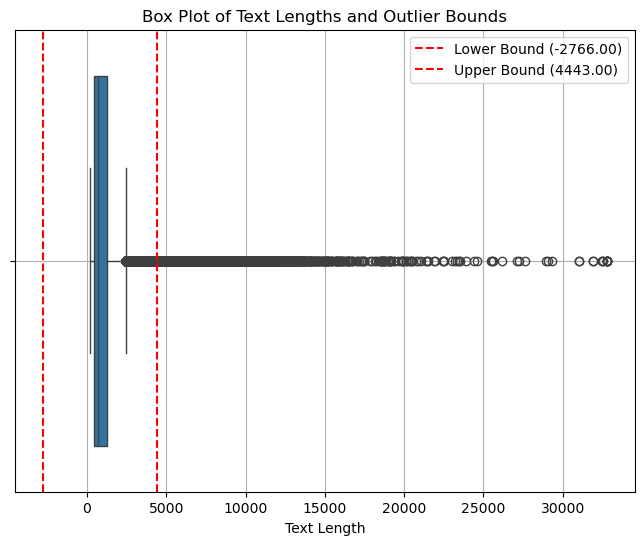

In [45]:
# BOX PLOT
plt.figure(figsize=(8, 6))
sns.boxplot(x=mental_df['text_length'])

# Add lines for the calculated bounds
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')

plt.title('Box Plot of Text Lengths and Outlier Bounds')
plt.xlabel('Text Length')
plt.legend()
plt.grid(True)

In [46]:
original_size = len(mental_df)

# Overwrite the 'df' variable with the filtered version
# This keeps only the rows WHERE the length is WITHIN the bounds
mental_df = mental_df[
    (mental_df['text_length'] >= lower_bound) & 
    (mental_df['text_length'] <= upper_bound)
]

new_size = len(mental_df)
rows_removed = original_size - new_size

print(f"Original dataset size: {original_size}")
print(f"New dataset size (without outliers): {new_size}")
print(f"Number of rows removed: {rows_removed}")

Original dataset size: 455082
New dataset size (without outliers): 448689
Number of rows removed: 6393


### Sampling

In [47]:
# Distribution of the classes before the removal in absolute values
print(mental_df['label'].value_counts())

# Distribution of the classes before the removal in percentuale
print(mental_df['label'].value_counts(normalize=True) * 100)

label
0    180055
3    135264
2     97501
1     27893
4      7976
Name: count, dtype: int64
label
0    40.129132
3    30.146493
2    21.730196
1     6.216555
4     1.777623
Name: proportion, dtype: float64


##### The following code balances the dataset by applying a fixed maximum cap of 8,000 samples per class. Classes exceeding this threshold are downsampled, while smaller classes are left unchanged. The resulting subsets are combined and shuffled to produce the final label distribution.


In [48]:
# original counts
original_counts = mental_df['label'].value_counts().sort_index()
print("Original counts:")
print(original_counts)
print()

# defining the maximum threshold (the "cap")
n_max = 8000

# Use groupby to handle each class separately in a single operation
df_final = mental_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), n_max), random_state=42)
)

# Reshuffle the final dataframe
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# final counts
final_counts = df_final['label'].value_counts().sort_index()

print("--- FINAL RESULT ---")
print(final_counts)
print(f"\nTotal size: {len(df_final)}")

Original counts:
label
0    180055
1     27893
2     97501
3    135264
4      7976
Name: count, dtype: int64

--- FINAL RESULT ---
label
0    8000
1    8000
2    8000
3    8000
4    7976
Name: count, dtype: int64

Total size: 39976


/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/2219622429.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = mental_df.groupby('label', group_keys=False).apply(


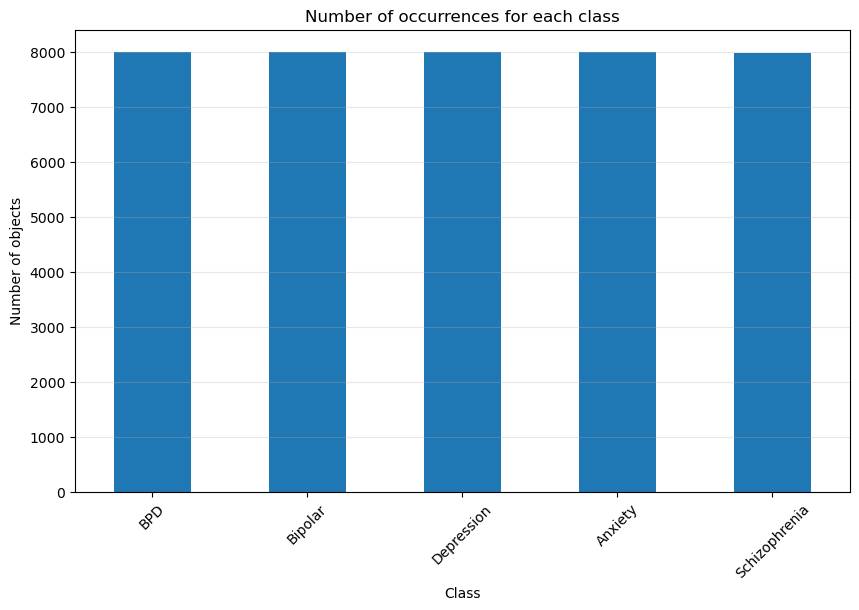

In [49]:
label_dict = {
    0: "BPD",
    1: "Bipolar",
    2: "Depression",
    3: "Anxiety",
    4: "Schizophrenia"
}

counts = df_final.groupby('label').size().sort_values(ascending=False)
plt.figure(figsize= (10,6))
counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Number of objects')

plt.xticks(ticks=range(len(counts)), labels=[label_dict[i] for i in counts.index], rotation=45)

plt.title('Number of occurrences for each class')
plt.grid(axis= 'y', alpha= 0.3)
plt.show()
plt.close()

/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_14339/1151959913.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')


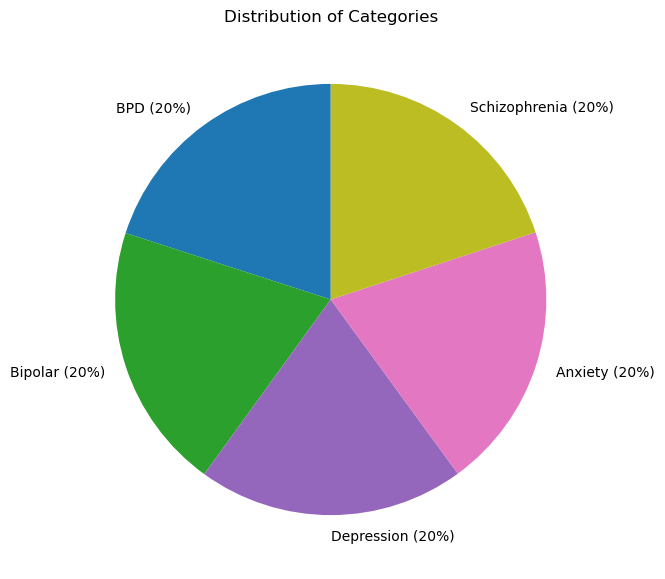

In [50]:
data = df_final.groupby('label').size().sort_values(ascending= False)
percentages = (data / data.sum()) * 100
labels = [f"{label_dict[label]} ({value:.0f}%)" for label, value in zip(data.index, percentages)]

cmap = get_cmap('tab20')
colors = [cmap(i / len(data)) for i in range(len(data))]

plt.figure(figsize=(10, 7))
plt.pie(
    data, 
    labels=labels,
    colors= colors,
    startangle=90
)
plt.title('Distribution of Categories')
plt.show()
plt.close()

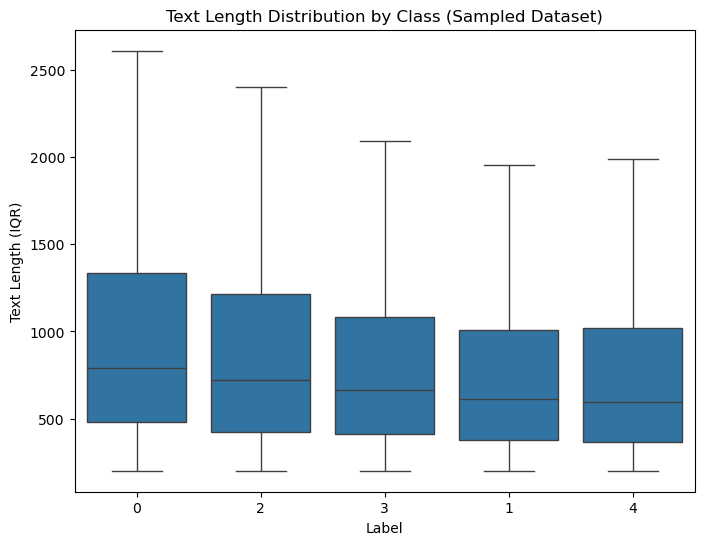

In [51]:
# --- BOX PLOT LENGTH BY CLASS ---

plt.figure(figsize=(8, 6))

# Order the boxes based on the new count
order = df_final['label'].value_counts().index

# 'showfliers=False' hides the outliers for a cleaner plot
sns.boxplot(data=df_final, x='label', y='text_length', order=order, showfliers=False)

plt.title('Text Length Distribution by Class (Sampled Dataset)')
plt.xlabel('Label')
plt.ylabel('Text Length (IQR)')
plt.show()

In [52]:
df_final

,text,label,text_length
0,I've had 4 in last year and noone knows. The l...,0,496
1,i saw this tiktok trend where you carve pumpki...,0,1435
2,Simple-type schizophrenia is characterized by ...,4,249
3,I m not sure if anything in here will be a tri...,2,959
4,Okay so I know this is a stupid situation but ...,3,610
...,...,...,...
39971,I'm currently in a position with my partner wh...,0,1183
39972,"Hello, I really don't know where to go for thi...",1,1117
39973,Hello again! I just wanted to come on here and...,4,334
39974,It works so well for me! It makes the rational...,0,862


### Save the final sampled dataset

In [53]:
# Save the final sampled dataset to a CSV file
# df_final.to_csv("sampled_mental_dataset.csv", index=False)